# McNemar's Test — Visual Summary
Reuses the predictions cached by the SigTest notebooks -- no models, no GPU
needed here. Produces two figures for the thesis:
1. A diverging bar chart: errors the ensemble corrected (green, right) vs.
   new errors it introduced (red, left), per baseline -- the exact quantity
   McNemar's test is built on.
2. A p-value bar chart (log scale) with the alpha=0.05 significance line.

## Cell 1 — Setup + load cached predictions

In [7]:
!pip install statsmodels -q
from statsmodels.stats.contingency_tables import mcnemar
import numpy as np
import pandas as pd
import json as jsonlib
import matplotlib.pyplot as plt

from google.colab import drive
drive.mount('/content/drive')

cache = '/content/drive/MyDrive/thesis_ensemble_outputs/significance_test_cache'

pred_swin = np.load(f'{cache}/pred_swin.npy')
pred_vit = np.load(f'{cache}/pred_vit.npy')
pred_resnet = np.load(f'{cache}/pred_resnet.npy')
pred_densenet = np.load(f'{cache}/pred_densenet.npy')
pred_efficientnet = np.load(f'{cache}/pred_efficientnet.npy')
pred_levit = np.load(f'{cache}/pred_levit.npy')
ensemble_probs = np.load(f'{cache}/ensemble_probs.npy')
true_labels = np.load(f'{cache}/true_labels.npy')

ensemble_preds = np.argmax(ensemble_probs, axis=1)
print("Loaded. Test set size:", len(true_labels))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loaded. Test set size: 2538


## Cell 2 — Recompute McNemar's test for all 6 comparisons

In [8]:
baselines = {
    "Swin": pred_swin,
    "ViT": pred_vit,
    "LeViT": pred_levit,
    "ResNet50": pred_resnet,
    "DenseNet121": pred_densenet,
    "EfficientNetB0": pred_efficientnet,
}

ensemble_correct = (ensemble_preds == true_labels)
rows = []

for name, preds in baselines.items():
    baseline_correct = (np.argmax(preds, axis=1) == true_labels)
    n10 = int(np.sum(baseline_correct & ~ensemble_correct))   # ensemble introduced a new error
    n01 = int(np.sum(~baseline_correct & ensemble_correct))   # ensemble corrected baseline's error
    n11 = int(np.sum(baseline_correct & ensemble_correct))
    n00 = int(np.sum(~baseline_correct & ~ensemble_correct))
    result = mcnemar([[n11, n10], [n01, n00]], exact=(n10 + n01 < 25), correction=True)
    rows.append({"Model": name, "corrected": n01, "introduced": n10,
                 "net_gain": n01 - n10, "p_value": float(result.pvalue)})

df = pd.DataFrame(rows).sort_values("net_gain", ascending=True)   # ascending so biggest net gain plots on top
print(df.to_string(index=False))

         Model  corrected  introduced  net_gain      p_value
          Swin         17           6        11 3.468966e-02
           ViT         22           6        16 4.586392e-03
      ResNet50         29           6        23 2.002676e-04
EfficientNetB0         35           5        30 4.533294e-06
   DenseNet121         56           6        50 4.877180e-10
         LeViT        101           7        94 3.589474e-19


## Cell 3 — Diverging bar chart: errors corrected vs. introduced

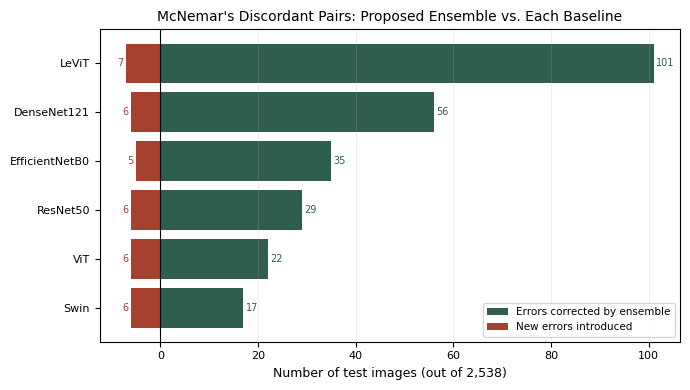

Saved to: /content/drive/MyDrive/thesis_ensemble_outputs/mcnemar_diverging_chart.png


In [9]:
fig, ax = plt.subplots(figsize=(7, 4))
y = np.arange(len(df))

ax.barh(y, df['corrected'], color='#2F5D50', label='Errors corrected by ensemble')
ax.barh(y, -df['introduced'], color='#A6402F', label='New errors introduced')

ax.axvline(0, color='black', linewidth=0.8)
ax.set_yticks(y)
ax.set_yticklabels(df['Model'], fontsize=8)
ax.set_xlabel('Number of test images (out of 2,538)', fontsize=9)
ax.set_title("McNemar's Discordant Pairs: Proposed Ensemble vs. Each Baseline", fontsize=10)
ax.tick_params(axis='x', labelsize=8)
ax.legend(fontsize=7.5, loc='lower right')
ax.grid(axis='x', alpha=0.3, linewidth=0.5)

for i, row in enumerate(df.itertuples()):
    ax.annotate(str(row.corrected), (row.corrected + 0.5, i), va='center', fontsize=7, color='#2F5D50')
    ax.annotate(str(row.introduced), (-row.introduced - 0.5, i), va='center', ha='right', fontsize=7, color='#A6402F')

plt.tight_layout()
output_folder = '/content/drive/MyDrive/thesis_ensemble_outputs'
plt.savefig(f'{output_folder}/mcnemar_diverging_chart.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved to: {output_folder}/mcnemar_diverging_chart.png")

## Cell 4 — p-value significance chart (log scale)

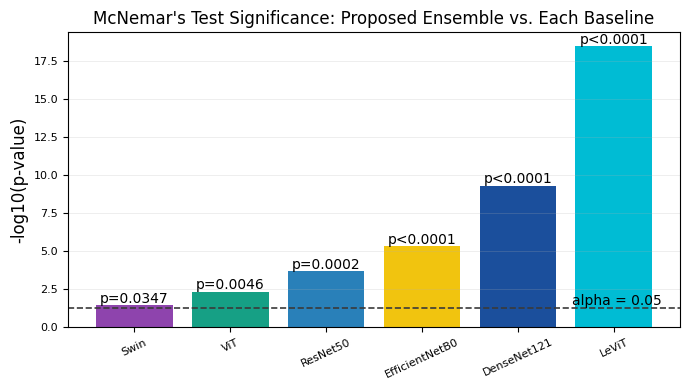

Saved to: /content/drive/MyDrive/thesis_ensemble_outputs/mcnemar_pvalue_chart.png


In [13]:
model_colors = {
   "Proposed Ensemble": "#2ECC71",   # bright green
"Swin":               "#8E44AD",  # deep purple
"ViT":                "#16A085",  # emerald teal
"ResNet50":           "#2980B9",  # strong blue
"EfficientNetB0":     "#F1C40F",  # golden yellow
"DenseNet121":        "#1B4F9C",  # deep indigo-blue
"LeViT":              "#00BCD4",  # bright cyan
}

df_p = df.sort_values("p_value", ascending=False).copy()
df_p["neg_log_p"] = -np.log10(df_p["p_value"].clip(lower=1e-300))

fig, ax = plt.subplots(figsize=(7, 4))
colors = [model_colors.get(m, "#8C8C8C") for m in df_p["Model"]]
bars = ax.bar(df_p['Model'], df_p['neg_log_p'], color=colors)

threshold = -np.log10(0.05)
ax.axhline(threshold, color='#3A3A3A', linestyle='--', linewidth=1.2)
ax.text(len(df_p) - 0.5, threshold + 0.15, 'alpha = 0.05', color='#000000', fontsize=10, ha='right')

ax.set_ylabel('-log10(p-value)', fontsize=12)
ax.set_title("McNemar's Test Significance: Proposed Ensemble vs. Each Baseline", fontsize=12)
ax.tick_params(axis='x', labelsize=8, rotation=25)
ax.tick_params(axis='y', labelsize=8)
ax.grid(axis='y', alpha=0.3, linewidth=0.5)

for i, row in enumerate(df_p.itertuples()):
    label = f"p={row.p_value:.4f}" if row.p_value >= 0.0001 else "p<0.0001"
    ax.annotate(label, (i, row.neg_log_p + 0.15), ha='center', fontsize=10)

plt.tight_layout()
plt.savefig(f'{output_folder}/mcnemar_pvalue_chart.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved to: {output_folder}/mcnemar_pvalue_chart.png")